# ESM25 Dataset Overview Figures

**Authors:** Spina Cianetti  
**License:** [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/)  
**Repository:** European Strong-Motion Database (ESM-DB)

---

This notebook reads the metadata CSV files produced by the ESM25 processing pipeline
and generates publication-ready figures illustrating the dataset composition:

1. **Dataset statistics** — number of events, records, bad vs good waveforms
2. **Epicentre map** — shaded-relief topographic map with earthquake epicentres
   (circle size ∝ magnitude, colour ∝ focal depth)
3. **Sample bad waveform** — CV acceleration for a record flagged as bad quality
4. **Sample good waveform** — CV acceleration, MP (acc/vel/dis), and response spectra

### Input files

| File | Description |
|------|-------------|
| `metadata_final.csv` | Good-quality records (aligned cv ∩ mp ∩ spectra) |
| `metadata_bad_final.csv` | Bad-quality records |
| `waveforms_good_cv.h5` | Good CV waveforms (3 comp, 84 000 samples @ 200 Hz) |
| `waveforms_good_mp.h5` | Good MP waveforms (9 comp, 60 000 samples @ 200 Hz) |
| `waveforms_bad_cv.h5` | Bad CV waveforms (3 comp, 84 000 samples @ 200 Hz) |
| `spectra_all.h5` | Response spectra (12 comp, 105 periods) |

---


## 1. Setup

In [3]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Paths ─────────────────────────────────────────────────────────────────────
# Adjust these paths to match your environment
DATA_DIR_1 = './'
DATA_DIR = '/home/jovyan/shared/users/spina/ESM25/h5_all_v4/'

METADATA_GOOD_CSV = os.path.join(DATA_DIR_1, 'metadata_final.csv')
METADATA_BAD_CSV  = os.path.join(DATA_DIR_1, 'metadata_bad_clean.csv')

H5_GOOD_CV  = os.path.join(DATA_DIR, 'waveforms_good_cv.h5')
H5_GOOD_MP  = os.path.join(DATA_DIR, 'waveforms_good_mp.h5')
H5_BAD_CV   = os.path.join(DATA_DIR, 'waveforms_bad_cv.h5')
H5_SPECTRA  = os.path.join(DATA_DIR, 'spectra_all.h5')

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

# ── Magnitude priority (same as pipeline) ─────────────────────────────────────
MAGNITUDE_COLS = ['source_emec_mw', 'source_mw', 'source_ml',
                  'source_ms', 'source_mb', 'source_md', 'source_m']

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
})


## 2. Load metadata

In [4]:
DTYPE_MAP = {
    'station_code':          str,
    'station_network_code':  str,
    'station_channel_code':  str,
    'station_location_code': str,
    'trace_u_channel_code':  str,
    'trace_v_channel_code':  str,
    'trace_w_channel_code':  str,
}

df_good = pd.read_csv(METADATA_GOOD_CSV, low_memory=False, dtype=DTYPE_MAP)
df_bad  = pd.read_csv(METADATA_BAD_CSV,  low_memory=False, dtype=DTYPE_MAP)

print(f"Good records : {len(df_good):,}")
print(f"Bad  records : {len(df_bad):,}")
print(f"Total        : {len(df_good) + len(df_bad):,}")
print()

# Unique events
n_ev_good = df_good['source_esm_id'].nunique()
n_ev_bad  = df_bad['source_esm_id'].nunique()
all_events = set(df_good['source_esm_id'].unique()) | set(df_bad['source_esm_id'].unique())
print(f"Unique events (good)  : {n_ev_good:,}")
print(f"Unique events (bad)   : {n_ev_bad:,}")
print(f"Unique events (total) : {len(all_events):,}")


Good records : 63,859
Bad  records : 36,036
Total        : 99,895

Unique events (good)  : 5,990
Unique events (bad)   : 4,475
Unique events (total) : 6,689


## 3. Assign preferred magnitude

In [5]:
def assign_preferred_magnitude(df, mag_cols=MAGNITUDE_COLS):
    """
    Assign preferred magnitude following priority order.
    Uses the first non-NaN value found across mag_cols.
    Also looks for generic 'source_magnitude' as final fallback.
    """
    # Build a list of actually-present columns
    present_cols = [c for c in mag_cols if c in df.columns]

    # Also check for a generic magnitude column
    if 'source_magnitude' in df.columns and 'source_magnitude' not in present_cols:
        present_cols.append('source_magnitude')

    if not present_cols:
        # Fallback: look for any column with 'mag' in the name
        mag_like = [c for c in df.columns if 'mag' in c.lower()]
        print(f"  ⚠ No standard magnitude columns found. Candidates: {mag_like}")
        if mag_like:
            present_cols = mag_like

    print(f"  Magnitude columns used (priority order): {present_cols}")

    mag_values = []
    mag_types  = []
    for _, row in df.iterrows():
        found = False
        for col in present_cols:
            val = row.get(col, np.nan)
            if pd.notna(val):
                try:
                    mag_values.append(float(val))
                    mag_types.append(col)
                    found = True
                    break
                except (ValueError, TypeError):
                    continue
        if not found:
            mag_values.append(np.nan)
            mag_types.append(None)

    df = df.copy()
    df['preferred_magnitude'] = mag_values
    df['magnitude_type'] = mag_types
    return df

df_good = assign_preferred_magnitude(df_good)
df_bad  = assign_preferred_magnitude(df_bad)

print(f"\nGood — magnitude assigned: {df_good['preferred_magnitude'].notna().sum():,} / {len(df_good):,}")
print(f"Bad  — magnitude assigned: {df_bad['preferred_magnitude'].notna().sum():,} / {len(df_bad):,}")


  ⚠ No standard magnitude columns found. Candidates: ['source_magnitude_ml', 'source_magnitude_ml_ref', 'source_magnitude_mw', 'source_magnitude_mw_ref', 'source_magnitude_ms', 'source_magnitude_ms_ref', 'source_magnitude_mb', 'source_magnitude_mb_ref', 'source_magnitude_md', 'source_magnitude_md_ref', 'source_magnitude_m', 'source_magnitude_m_ref', 'source_magnitude_emec_mw', 'source_magnitude_emec_mw_type', 'source_magnitude_emec_mw_ref']
  Magnitude columns used (priority order): ['source_magnitude_ml', 'source_magnitude_ml_ref', 'source_magnitude_mw', 'source_magnitude_mw_ref', 'source_magnitude_ms', 'source_magnitude_ms_ref', 'source_magnitude_mb', 'source_magnitude_mb_ref', 'source_magnitude_md', 'source_magnitude_md_ref', 'source_magnitude_m', 'source_magnitude_m_ref', 'source_magnitude_emec_mw', 'source_magnitude_emec_mw_type', 'source_magnitude_emec_mw_ref']
  ⚠ No standard magnitude columns found. Candidates: ['source_magnitude_ml', 'source_magnitude_ml_ref', 'source_magnitud

## 4. Build event catalogue for the map

Deduplicate to one row per event, keeping source coordinates, depth,
and the preferred magnitude.

In [6]:
def build_event_catalogue(df, label=''):
    """Aggregate per-record metadata to unique events."""
    # Detect coordinate column names (ESM uses source_latitude_deg / source_longitude_deg)
    lat_col = next((c for c in df.columns if c in ['source_latitude_deg', 'source_latitude']), None)
    lon_col = next((c for c in df.columns if c in ['source_longitude_deg', 'source_longitude']), None)
    depth_col = next((c for c in df.columns if c in ['source_depth_km', 'source_depth']), None)

    if lat_col is None or lon_col is None:
        raise KeyError(f"Cannot find lat/lon columns. Available: {[c for c in df.columns if 'source' in c]}")

    print(f"  [{label}] Using columns: lat={lat_col}, lon={lon_col}, depth={depth_col}")

    cols_to_keep = ['source_esm_id', lat_col, lon_col, 'preferred_magnitude']
    if depth_col:
        cols_to_keep.append(depth_col)

    # Take first non-null per event
    agg = {c: 'first' for c in cols_to_keep if c != 'source_esm_id'}
    ev = df[cols_to_keep].groupby('source_esm_id').agg(agg).reset_index()

    # Standardise column names
    ev = ev.rename(columns={
        lat_col: 'latitude',
        lon_col: 'longitude',
    })
    if depth_col and depth_col in ev.columns:
        ev = ev.rename(columns={depth_col: 'depth_km'})
    else:
        ev['depth_km'] = np.nan

    return ev

ev_good = build_event_catalogue(df_good, 'good')
ev_bad  = build_event_catalogue(df_bad,  'bad')

# Combined catalogue (some events may appear in both)
ev_all = pd.concat([ev_good, ev_bad], ignore_index=True)
ev_all = ev_all.groupby('source_esm_id').first().reset_index()
ev_all = ev_all.dropna(subset=['latitude', 'longitude', 'preferred_magnitude'])

print(f"\nEvents for map: {len(ev_all):,} (with valid coordinates and magnitude)")
print(f"  Depth available: {ev_all['depth_km'].notna().sum():,}")
print(f"  Magnitude range: {ev_all['preferred_magnitude'].min():.1f} – {ev_all['preferred_magnitude'].max():.1f}")
print(f"  Depth range    : {ev_all['depth_km'].min():.1f} – {ev_all['depth_km'].max():.1f} km")


  [good] Using columns: lat=source_latitude_deg, lon=source_longitude_deg, depth=source_depth_km
  [bad] Using columns: lat=source_latitude_deg, lon=source_longitude_deg, depth=source_depth_km

Events for map: 6,689 (with valid coordinates and magnitude)
  Depth available: 6,665
  Magnitude range: 2.3 – 7.7
  Depth range    : -0.3 – 620.6 km


## 5. Figure 1 — Dataset statistics

Summary bar chart showing the number of events, good records, and bad records.

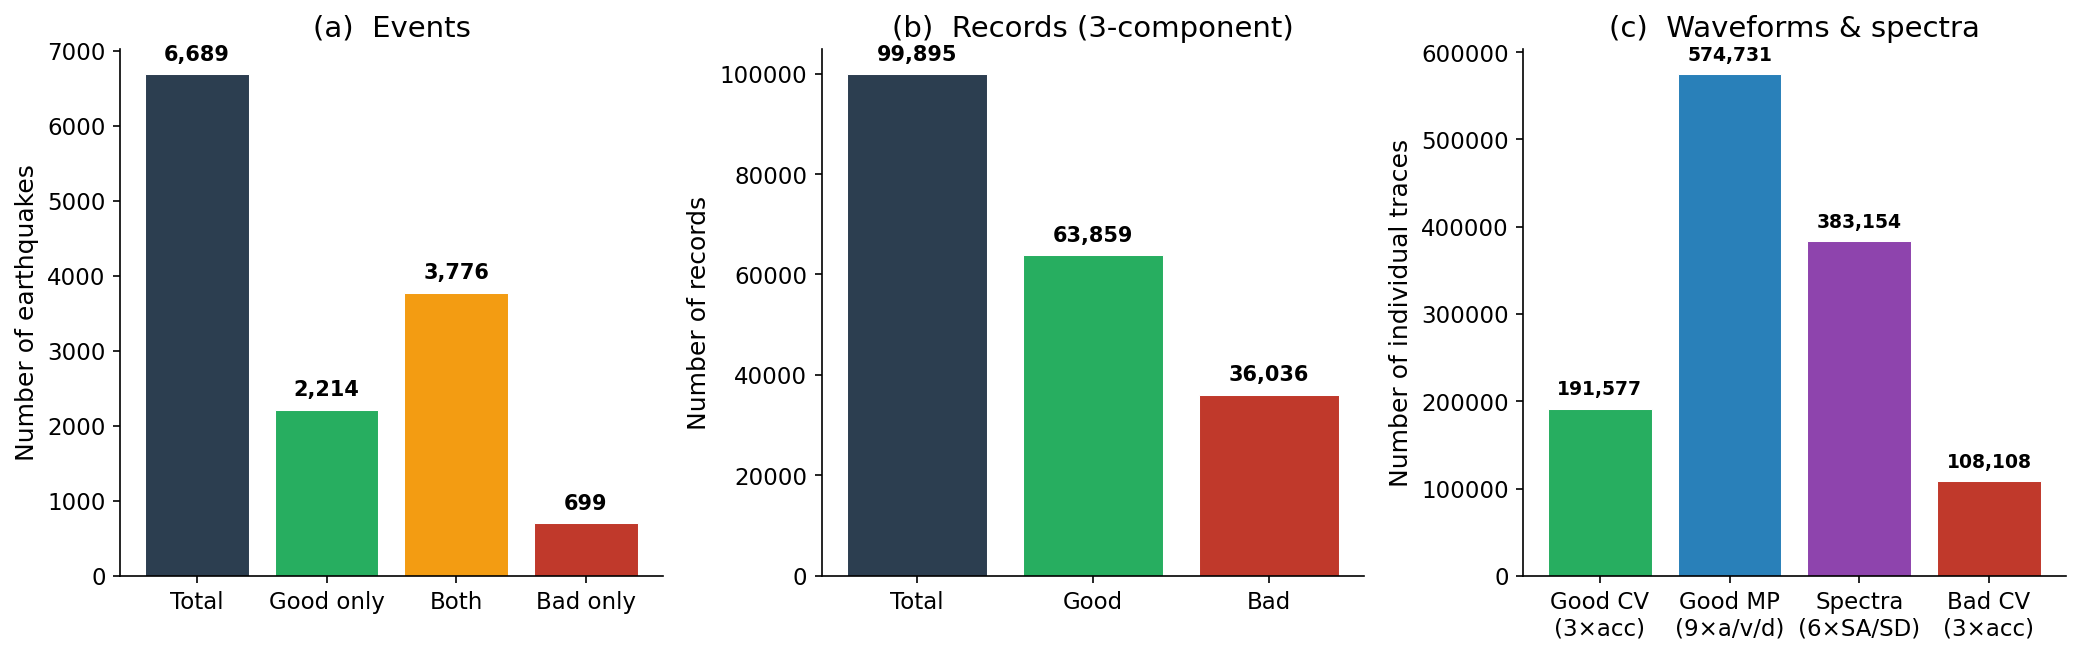

✓ Saved dataset_statistics.png / .pdf


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Panel A: event counts ──
n_ev_only_good = len(set(df_good['source_esm_id']) - set(df_bad['source_esm_id']))
n_ev_only_bad  = len(set(df_bad['source_esm_id']) - set(df_good['source_esm_id']))
n_ev_both      = len(set(df_good['source_esm_id']) & set(df_bad['source_esm_id']))

bars_ev = [len(all_events), n_ev_only_good, n_ev_both, n_ev_only_bad]
labels_ev = ['Total', 'Good only', 'Both', 'Bad only']
colors_ev = ['#2c3e50', '#27ae60', '#f39c12', '#c0392b']

ax = axes[0]
b = ax.bar(labels_ev, bars_ev, color=colors_ev, edgecolor='white', linewidth=0.5)
for bar, val in zip(b, bars_ev):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bars_ev)*0.02,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of earthquakes')
ax.set_title('(a)  Events')
ax.spines[['top', 'right']].set_visible(False)

# ── Panel B: record counts ──
bars_rec = [len(df_good) + len(df_bad), len(df_good), len(df_bad)]
labels_rec = ['Total', 'Good', 'Bad']
colors_rec = ['#2c3e50', '#27ae60', '#c0392b']

ax = axes[1]
b = ax.bar(labels_rec, bars_rec, color=colors_rec, edgecolor='white', linewidth=0.5)
for bar, val in zip(b, bars_rec):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bars_rec)*0.02,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of records')
ax.set_title('(b)  Records (3-component)')
ax.spines[['top', 'right']].set_visible(False)

# ── Panel C: waveform counts ──
n_wf_good_cv = len(df_good) * 3
n_wf_good_mp = len(df_good) * 9
n_wf_bad_cv  = len(df_bad) * 3
n_wf_spectra = len(df_good) * 6  # 3 SA + 3 SD per record

bars_wf = [n_wf_good_cv, n_wf_good_mp, n_wf_spectra, n_wf_bad_cv]
labels_wf = ['Good CV\n(3×acc)', 'Good MP\n(9×a/v/d)', 'Spectra\n(6×SA/SD)', 'Bad CV\n(3×acc)']
colors_wf = ['#27ae60', '#2980b9', '#8e44ad', '#c0392b']

ax = axes[2]
b = ax.bar(labels_wf, bars_wf, color=colors_wf, edgecolor='white', linewidth=0.5)
for bar, val in zip(b, bars_wf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bars_wf)*0.02,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Number of individual traces')
ax.set_title('(c)  Waveforms & spectra')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'dataset_statistics.png'))
plt.savefig(os.path.join(FIGURE_DIR, 'dataset_statistics.pdf'))
plt.show()
print("✓ Saved dataset_statistics.png / .pdf")


## 6. Figure 2 — Epicentre map

Shaded-relief topographic background (grayscale) with earthquake epicentres
plotted as circles whose **size is proportional to magnitude** and
**colour is proportional to focal depth**.

/opt/conda/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


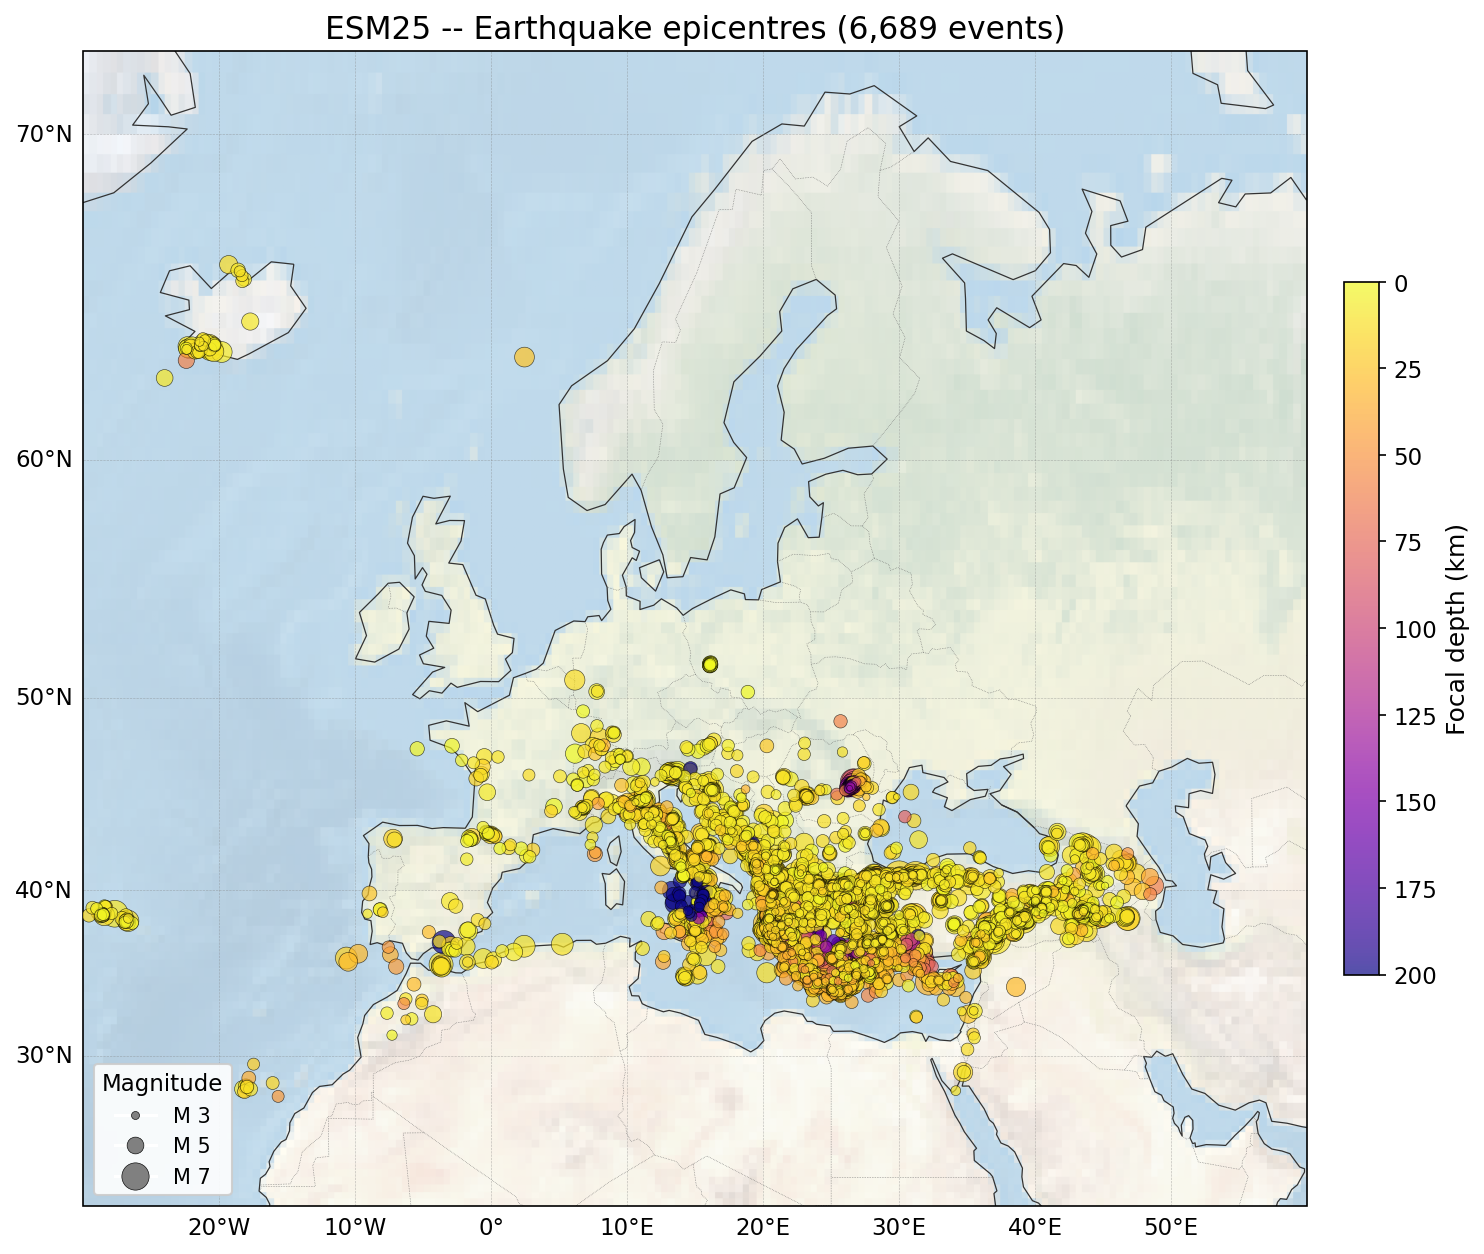

Saved epicentre_map.png / .pdf


In [8]:
# -- Map extent (Euro-Mediterranean + Middle East) ----
LON_MIN, LON_MAX = -30, 60
LAT_MIN, LAT_MAX =  20, 72

# -- Magnitude -> marker size mapping --
def mag_to_size(mag, min_size=4, max_size=250, mag_min=1.0, mag_max=8.0):
    """Map magnitude to scatter marker area."""
    m = np.clip(mag, mag_min, mag_max)
    frac = (m - mag_min) / (mag_max - mag_min)
    return min_size + frac**2.5 * (max_size - min_size)

# -- Depth colormap (warm = shallow, cool = deep) --
depth_cmap = plt.cm.plasma_r
depth_min, depth_max = 0, 200
depth_norm = mcolors.Normalize(vmin=depth_min, vmax=depth_max)

# -- Sort by magnitude (plot small on top of large for visibility) --
ev_plot = ev_all.sort_values('preferred_magnitude', ascending=False).copy()
ev_plot['depth_km'] = ev_plot['depth_km'].fillna(10)
ev_plot['marker_size'] = mag_to_size(ev_plot['preferred_magnitude'].values)

# -- Figure --
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())

# Shaded relief background -- fully offline, desaturated to grayscale
ax.stock_img()

# Overlay semi-transparent white rectangle to wash out colours -> grayscale
from matplotlib.patches import Rectangle
bg_rect = Rectangle(
    (LON_MIN - 5, LAT_MIN - 5),
    (LON_MAX - LON_MIN) + 10,
    (LAT_MAX - LAT_MIN) + 10,
    transform=ccrs.PlateCarree(), facecolor='white', alpha=0.50, zorder=1,
)
ax.add_patch(bg_rect)

# Country borders and coastlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='#333333', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, color='#666666', linestyle=':', zorder=2)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5,
                   linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

# Plot epicentres
sc = ax.scatter(
    ev_plot['longitude'].values,
    ev_plot['latitude'].values,
    s=ev_plot['marker_size'].values,
    c=ev_plot['depth_km'].values,
    cmap=depth_cmap,
    norm=depth_norm,
    alpha=0.7,
    edgecolors='k',
    linewidths=0.3,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Depth colour bar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02,
                     label='Focal depth (km)')
cbar.ax.invert_yaxis()

# Magnitude legend (reference circles)
mag_legend_vals = [3, 5, 7]
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(mag_to_size(m)), label=f'M {m}',
           markeredgecolor='k', markeredgewidth=0.3)
    for m in mag_legend_vals
]
ax.legend(handles=legend_elements, title='Magnitude', loc='lower left',
          framealpha=0.9, fontsize=10, title_fontsize=11)

ax.set_title(f'ESM25 -- Earthquake epicentres ({len(ev_plot):,} events)', fontsize=15)

plt.savefig(os.path.join(FIGURE_DIR, 'epicentre_map.png'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURE_DIR, 'epicentre_map.pdf'), bbox_inches='tight')
plt.show()
print("Saved epicentre_map.png / .pdf")


## 7. Figure 3 — Sample bad-quality waveform

Shows the 3-component CV acceleration for a randomly selected bad-quality record.

In [ ]:
# Pick a random bad record (fixed seed for reproducibility)
rng = np.random.default_rng(42)
idx_bad = rng.integers(0, len(df_bad))
row_bad = df_bad.iloc[idx_bad]
trace_name_bad = row_bad['trace_name']

print(f"Bad record : {trace_name_bad}")
print(f"Event      : {row_bad['source_esm_id']}")

# Read waveform from HDF5
with h5py.File(H5_BAD_CV, 'r') as f:
    wf_bad = f['data'][trace_name_bad][()]  # shape: (3, 84000)

n_comp, n_samp = wf_bad.shape
dt = 1.0 / 200.0  # 200 Hz
time_axis = np.arange(n_samp) * dt

comp_labels = ['U (East)', 'V (North)', 'W (Up)']
comp_colors = ['#c0392b', '#2980b9', '#27ae60']

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True, sharey=False)
fig.suptitle(f'Bad-quality waveform — {trace_name_bad}', fontsize=14, fontweight='bold')

for i, (ax, label, color) in enumerate(zip(axes, comp_labels, comp_colors)):
    ax.plot(time_axis, wf_bad[i], color=color, linewidth=0.4, alpha=0.9)
    ax.set_ylabel(f'{label}\n(m/s²)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3)
    # Show peak value
    peak = np.abs(wf_bad[i]).max()
    ax.text(0.98, 0.92, f'PGA = {peak:.4f} m/s²', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

axes[-1].set_xlabel('Time (s)')
axes[-1].set_xlim(0, time_axis[-1])

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'sample_bad_waveform.png'))
plt.savefig(os.path.join(FIGURE_DIR, 'sample_bad_waveform.pdf'))
plt.show()
print("✓ Saved sample_bad_waveform.png / .pdf")


Bad record : EMSC-20131206_0000061.HL.KSL.00.HN
Event      : EMSC-20131206_0000061


## 8. Figure 4 — Sample good-quality waveform

A 4-row panel showing a randomly selected good-quality record:
- **Row 1**: CV acceleration (3 components, 420 s)
- **Row 2**: MP acceleration (3 components, 300 s)
- **Row 3**: MP velocity and displacement (6 components, 300 s)
- **Row 4**: Response spectra SA and SD (6 components, 105 periods)

In [ ]:
# Pick a random good record
idx_good = rng.integers(0, len(df_good))
row_good = df_good.iloc[idx_good]
trace_name_good = row_good['trace_name']

print(f"Good record : {trace_name_good}")
print(f"Event       : {row_good['source_esm_id']}")

# Read all three HDF5 files
with h5py.File(H5_GOOD_CV, 'r') as f:
    wf_cv = f['data'][trace_name_good][()]   # (3, 84000)

with h5py.File(H5_GOOD_MP, 'r') as f:
    wf_mp = f['data'][trace_name_good][()]   # (9, 60000)

with h5py.File(H5_SPECTRA, 'r') as f:
    sp = f['spectra'][trace_name_good][()]   # (12, 105)
    periods = f['Period'][()]                 # (105,)

# Time axes
dt_cv = 1.0 / 200.0
dt_mp = 1.0 / 200.0
t_cv = np.arange(wf_cv.shape[1]) * dt_cv
t_mp = np.arange(wf_mp.shape[1]) * dt_mp

# Component labels
cv_labels = ['acc U', 'acc V', 'acc W']
# MP order: acc_u, acc_v, acc_w, vel_u, vel_v, vel_w, dis_u, dis_v, dis_w
mp_acc_labels = ['acc U', 'acc V', 'acc W']
mp_vel_labels = ['vel U', 'vel V', 'vel W']
mp_dis_labels = ['dis U', 'dis V', 'dis W']
# Spectra order: SA_acc_u, SA_acc_v, SA_acc_w, SA_dis_u, SA_dis_v, SA_dis_w,
#                SD_acc_u, SD_acc_v, SD_acc_w, SD_dis_u, SD_dis_v, SD_dis_w
# Actually: (SA_u, SA_v, SA_w, SD_u, SD_v, SD_w) × 2 sets — adjust if needed

comp_colors_3 = ['#c0392b', '#2980b9', '#27ae60']

fig = plt.figure(figsize=(16, 14))
fig.suptitle(f'Good-quality record — {trace_name_good}', fontsize=14, fontweight='bold', y=0.98)

# ── Row 1: CV acceleration ──
for i in range(3):
    ax = fig.add_subplot(5, 3, i + 1)
    ax.plot(t_cv, wf_cv[i], color=comp_colors_3[i], linewidth=0.3)
    ax.set_title(f'CV {cv_labels[i]}', fontsize=10)
    if i == 0:
        ax.set_ylabel('Acc (m/s²)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, t_cv[-1])

# ── Row 2: MP acceleration ──
for i in range(3):
    ax = fig.add_subplot(5, 3, 3 + i + 1)
    ax.plot(t_mp, wf_mp[i], color=comp_colors_3[i], linewidth=0.3)
    ax.set_title(f'MP {mp_acc_labels[i]}', fontsize=10)
    if i == 0:
        ax.set_ylabel('Acc (m/s²)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, t_mp[-1])

# ── Row 3: MP velocity ──
for i in range(3):
    ax = fig.add_subplot(5, 3, 6 + i + 1)
    ax.plot(t_mp, wf_mp[3 + i], color=comp_colors_3[i], linewidth=0.3)
    ax.set_title(f'MP {mp_vel_labels[i]}', fontsize=10)
    if i == 0:
        ax.set_ylabel('Vel (m/s)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, t_mp[-1])

# ── Row 4: MP displacement ──
for i in range(3):
    ax = fig.add_subplot(5, 3, 9 + i + 1)
    ax.plot(t_mp, wf_mp[6 + i], color=comp_colors_3[i], linewidth=0.3)
    ax.set_title(f'MP {mp_dis_labels[i]}', fontsize=10)
    if i == 0:
        ax.set_ylabel('Disp (m)')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, t_mp[-1])
    ax.set_xlabel('Time (s)')

# ── Row 5: Response spectra (SA and SD) ──
ax_sa = fig.add_subplot(5, 3, 13)
ax_sd = fig.add_subplot(5, 3, 14)

# SA components: first 3 (or 6) of the spectra array
n_spec_comp = sp.shape[0]
n_sa = n_spec_comp // 2  # first half = SA, second half = SD
sa_labels = ['SA U', 'SA V', 'SA W'] if n_sa >= 3 else [f'SA {i}' for i in range(n_sa)]
sd_labels = ['SD U', 'SD V', 'SD W'] if n_sa >= 3 else [f'SD {i}' for i in range(n_sa)]

for i in range(min(3, n_sa)):
    ax_sa.loglog(periods, sp[i], color=comp_colors_3[i], linewidth=1.2, label=sa_labels[i])
    ax_sd.loglog(periods, sp[n_sa + i], color=comp_colors_3[i], linewidth=1.2,
                 label=sd_labels[i])

ax_sa.set_title('SA (acceleration spectra)', fontsize=10)
ax_sa.set_xlabel('Period (s)')
ax_sa.set_ylabel('SA (m/s²)')
ax_sa.legend(fontsize=8)
ax_sa.grid(True, alpha=0.3, which='both')
ax_sa.spines[['top', 'right']].set_visible(False)

ax_sd.set_title('SD (displacement spectra)', fontsize=10)
ax_sd.set_xlabel('Period (s)')
ax_sd.set_ylabel('SD (m)')
ax_sd.legend(fontsize=8)
ax_sd.grid(True, alpha=0.3, which='both')
ax_sd.spines[['top', 'right']].set_visible(False)

# Hide the 15th subplot (3rd in row 5)
fig.add_subplot(5, 3, 15).set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'sample_good_waveform.png'))
plt.savefig(os.path.join(FIGURE_DIR, 'sample_good_waveform.pdf'))
plt.show()
print("✓ Saved sample_good_waveform.png / .pdf")


## 9. Figure 5 — PGA, PGV and PGD distributions (good dataset)

Histograms of Peak Ground Acceleration (PGA), Peak Ground Velocity (PGV)
and Peak Ground Displacement (PGD) for the good-quality dataset.
Values are shown in log₁₀ scale on the x-axis.
The code auto-detects available columns and uses RotD50 if available,
otherwise the geometric mean of the three components.

In [ ]:
# --- PGA, PGV, PGD columns in ESM25 metadata ---
# Naming convention: trace_{comp}_{measure}_{unit}
#   comp:    u, v, w, rotd50, rotd100, rotd00
#   measure: pga, pgv, pgd
#   unit:    cps2 (cm/s^2), cps (cm/s), c (cm)
# We use RotD50 as the representative value.

peak_config = {
    'pga': {
        'col': 'trace_rotd50_pga_cps2',
        'unit_label': r'cm/s$^2$',
        'title': 'PGA',
        'fallback': ['trace_u_pga_cps2', 'trace_v_pga_cps2', 'trace_w_pga_cps2'],
    },
    'pgv': {
        'col': 'trace_rotd50_pgv_cps',
        'unit_label': r'cm/s',
        'title': 'PGV',
        'fallback': ['trace_u_pgv_cps', 'trace_v_pgv_cps', 'trace_w_pgv_cps'],
    },
    'pgd': {
        'col': 'trace_rotd50_pgd_c',
        'unit_label': r'cm',
        'title': 'PGD',
        'fallback': ['trace_u_pgd_c', 'trace_v_pgd_c', 'trace_w_pgd_c'],
    },
}

peak_data = {}
for key, cfg in peak_config.items():
    if cfg['col'] in df_good.columns:
        series = pd.to_numeric(df_good[cfg['col']], errors='coerce')
        method = cfg['col']
    else:
        # Fallback: geometric mean of per-component columns
        available = [c for c in cfg['fallback'] if c in df_good.columns]
        if available:
            vals = df_good[available].apply(pd.to_numeric, errors='coerce')
            series = np.exp(np.log(vals.clip(lower=1e-15)).mean(axis=1))
            method = f"geomean({available})"
        else:
            series = None
            method = None
    
    if series is not None:
        peak_data[key] = (series, method, cfg['unit_label'], cfg['title'])
        n_valid = series.dropna().gt(0).sum()
        print(f"{cfg['title']}: using {method}  ({n_valid:,} valid values)")
    else:
        print(f"{cfg['title']}: no column found")

# --- Plot ---
n_panels = len(peak_data)
if n_panels == 0:
    print("\n  No PGA/PGV/PGD columns found.")
    print("  Columns with 'pg':", [c for c in df_good.columns if 'pg' in c.lower()])
else:
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]
    
    panel_labels = 'abcdefgh'
    
    for i, key in enumerate(k for k in ['pga', 'pgv', 'pgd'] if k in peak_data):
        ax = axes[i]
        series, method, unit_label, title = peak_data[key]
        
        valid = series.dropna()
        valid = valid[valid > 0]
        log_vals = np.log10(valid.values.astype(float))
        log_vals = log_vals[np.isfinite(log_vals)]
        
        vmin, vmax = np.percentile(log_vals, [0.5, 99.5])
        bins = np.linspace(vmin - 0.2, vmax + 0.2, 70)
        
        ax.hist(log_vals, bins=bins, alpha=0.75, color='#2980b9', edgecolor='white',
                linewidth=0.3)
        
        median_val = np.median(log_vals)
        ax.axvline(median_val, color='#c0392b', linestyle='--', linewidth=1.5,
                   label=f'Median: {10**median_val:.3g} {unit_label}')
        
        ax.set_xlabel(rf'log$_{{10}}$ {title} ({unit_label})', fontsize=12)
        ax.set_ylabel('Count', fontsize=12)
        ax.set_title(f'({panel_labels[i]})  {title} RotD50  (n = {len(log_vals):,})',
                     fontsize=13)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, 'pga_pgv_pgd_distribution.png'), bbox_inches='tight')
    plt.savefig(os.path.join(FIGURE_DIR, 'pga_pgv_pgd_distribution.pdf'), bbox_inches='tight')
    plt.show()
    print("Saved pga_pgv_pgd_distribution.png / .pdf")


## 10. Figure 6 — RotD100 vs RotD50 comparison

The ratio RotD100/RotD50 quantifies how directionally polarised the ground
shaking is at each record. A ratio close to 1 indicates nearly isotropic
horizontal motion; larger values indicate strong directional effects.
Note that RotD measures are orientation-independent by construction, so
they reveal the *degree* of polarisation but not its azimuth.

In [ ]:
# --- RotD100 vs RotD50 for PGA, PGV, PGD ---
rotd_config = {
    'pga': {'d50': 'trace_rotd50_pga_cps2', 'd100': 'trace_rotd100_pga_cps2',
            'unit': r'cm/s$^2$', 'title': 'PGA'},
    'pgv': {'d50': 'trace_rotd50_pgv_cps',  'd100': 'trace_rotd100_pgv_cps',
            'unit': r'cm/s',    'title': 'PGV'},
    'pgd': {'d50': 'trace_rotd50_pgd_c',    'd100': 'trace_rotd100_pgd_c',
            'unit': r'cm',      'title': 'PGD'},
}

# Keep only measures present in both d50 and d100
available_rotd = {k: v for k, v in rotd_config.items()
                  if v['d50'] in df_good.columns and v['d100'] in df_good.columns}

n = len(available_rotd)
if n == 0:
    print("No RotD50/RotD100 column pairs found.")
else:
    fig, axes = plt.subplots(2, n, figsize=(6 * n, 10))
    if n == 1:
        axes = axes.reshape(2, 1)
    
    panel_labels = 'abcdefgh'
    
    for i, (key, cfg) in enumerate(available_rotd.items()):
        d50  = pd.to_numeric(df_good[cfg['d50']],  errors='coerce')
        d100 = pd.to_numeric(df_good[cfg['d100']], errors='coerce')
        
        mask = (d50 > 0) & (d100 > 0) & d50.notna() & d100.notna()
        d50_v  = d50[mask].values
        d100_v = d100[mask].values
        ratio  = d100_v / d50_v
        
        # --- Top row: scatter RotD100 vs RotD50 (log-log) ---
        ax = axes[0, i]
        ax.scatter(np.log10(d50_v), np.log10(d100_v), s=1, alpha=0.15,
                   color='#2980b9', rasterized=True)
        
        # 1:1 line
        lims = [min(np.log10(d50_v).min(), np.log10(d100_v).min()) - 0.2,
                max(np.log10(d50_v).max(), np.log10(d100_v).max()) + 0.2]
        ax.plot(lims, lims, 'k--', linewidth=0.8, label='1:1')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(rf'log$_{{10}}$ RotD50 {cfg["title"]} ({cfg["unit"]})', fontsize=11)
        ax.set_ylabel(rf'log$_{{10}}$ RotD100 {cfg["title"]} ({cfg["unit"]})', fontsize=11)
        ax.set_title(f'({panel_labels[i]})  {cfg["title"]}  (n = {len(d50_v):,})', fontsize=12)
        ax.set_aspect('equal')
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.2)
        
        # --- Bottom row: histogram of RotD100/RotD50 ratio ---
        ax = axes[1, i]
        bins = np.linspace(0.8, 3.0, 80)
        ax.hist(ratio, bins=bins, alpha=0.75, color='#8e44ad', edgecolor='white',
                linewidth=0.3)
        
        med = np.median(ratio)
        ax.axvline(med, color='#c0392b', linestyle='--', linewidth=1.5,
                   label=f'Median: {med:.2f}')
        ax.axvline(1.0, color='k', linestyle=':', linewidth=0.8,
                   label='Isotropic (1.0)')
        
        ax.set_xlabel(f'RotD100 / RotD50  ({cfg["title"]})', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'({panel_labels[n + i]})  {cfg["title"]} polarisation ratio', fontsize=12)
        ax.legend(fontsize=9, framealpha=0.9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, 'rotd100_vs_rotd50.png'), bbox_inches='tight')
    plt.savefig(os.path.join(FIGURE_DIR, 'rotd100_vs_rotd50.pdf'), bbox_inches='tight')
    plt.show()
    print(f"Saved rotd100_vs_rotd50.png / .pdf")


## 11. Figure 7 — Station map

Map of all seismic stations in the dataset, shown as triangles.
The triangle size is proportional to the number of records
(appearances in the metadata) for each station.

In [ ]:
# --- Build station catalogue from good + bad metadata ---
df_all = pd.concat([df_good, df_bad], ignore_index=True)

# Station key: network.station
df_all['_sta_key'] = (
    df_all['station_network_code'].astype(str).str.strip() + '.' +
    df_all['station_code'].astype(str).str.strip()
)

# Aggregate: count records, take first lat/lon
sta_agg = df_all.groupby('_sta_key').agg(
    n_records=('_sta_key', 'size'),
    latitude=('station_latitude_deg', 'first'),
    longitude=('station_longitude_deg', 'first'),
).reset_index()

sta_agg = sta_agg.dropna(subset=['latitude', 'longitude'])
sta_agg['latitude']  = pd.to_numeric(sta_agg['latitude'],  errors='coerce')
sta_agg['longitude'] = pd.to_numeric(sta_agg['longitude'], errors='coerce')
sta_agg = sta_agg.dropna(subset=['latitude', 'longitude'])

print(f"Unique stations: {len(sta_agg):,}")
print(f"Records per station: min={sta_agg['n_records'].min()}, "
      f"median={sta_agg['n_records'].median():.0f}, "
      f"max={sta_agg['n_records'].max()}")

# Sort so that high-count stations are drawn on top
sta_plot = sta_agg.sort_values('n_records', ascending=True)

# --- Map ---
LON_MIN, LON_MAX = -30, 60
LAT_MIN, LAT_MAX =  20, 72

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())

# Background
ax.stock_img()
from matplotlib.patches import Rectangle
bg_rect = Rectangle(
    (LON_MIN - 5, LAT_MIN - 5),
    (LON_MAX - LON_MIN) + 10,
    (LAT_MAX - LAT_MIN) + 10,
    transform=ccrs.PlateCarree(), facecolor='white', alpha=0.50, zorder=1,
)
ax.add_patch(bg_rect)

ax.add_feature(cfeature.COASTLINE, linewidth=0.6, color='#333333', zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, color='#666666', linestyle=':', zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5,
                   linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

# Plot stations as triangles — fixed size, colour = number of records
sc = ax.scatter(
    sta_plot['longitude'].values,
    sta_plot['latitude'].values,
    s=30,
    c=sta_plot['n_records'].values,
    cmap='YlOrRd',
    norm=mcolors.LogNorm(vmin=max(1, sta_agg['n_records'].min()),
                         vmax=sta_agg['n_records'].max()),
    marker='^',
    alpha=0.85,
    edgecolors='k',
    linewidths=0.3,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02,
                     label='Number of records')

ax.set_title(f'ESM25 \u2014 Seismic stations ({len(sta_plot):,} stations)', fontsize=15)

plt.savefig(os.path.join(FIGURE_DIR, 'station_map.png'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURE_DIR, 'station_map.pdf'), bbox_inches='tight')
plt.show()
print(f"Saved station_map.png / .pdf")
